

# Proyecto 2

### Universidad de Medellin
### Facultad de ingenierias
### Ingenieria financiera
### Autores: Joseph Garcia Llano y Jaime Castro  


## Company Bankruptcy Prediction

Este conjunto de datos pertenece al dominio de las finanzas corporativas, la gestión de riesgo crediticio y la evaluación de salud financiera empresarial. Los datos provienen del *Taiwan Economic Journal* (TEJ) y cubren el periodo 1999-2009. La condición de "quiebra" se definió con base en las regulaciones de la Bolsa de Valores de Taiwán (Taiwan Stock Exchange).

La base contiene **6,819 empresas** y **95 variables predictoras**, todas indicadores financieros (razones de liquidez, rentabilidad, apalancamiento, rotación de activos y flujo de caja, entre otras), más la variable objetivo `Bankrupt?` (1 = la empresa entró en quiebra, 0 = no lo hizo).

* Utilidad:
  * Evaluación automatizada del riesgo de crédito para conceder préstamos, determinar tasas de interés o fijar cupos crediticios.
  * Alerta temprana de dificultades financieras para inversionistas y reguladores.

* Variable de salida (target):
  * `Bankrupt?`: variable binaria (1 = quiebra, 0 = no quiebra).



### Tipo de problema

Desde la perspectiva de aprendizaje automático, este es un problema de **aprendizaje supervisado de clasificación binaria**: a partir de un vector de 95 variables predictoras (todas numéricas, razones financieras) se busca predecir una etiqueta binaria, `Bankrupt?` (0 = empresa solvente, 1 = empresa en quiebra). Cada fila corresponde a una empresa observada en un momento dado; el dataset es de corte transversal (no es una serie de tiempo por empresa), aunque en conjunto las 6,819 observaciones abarcan el periodo 1999-2009.


### Panorama general de las variables

El dataset original identifica sus 95 variables solo por el nombre de la razón financiera, sin agruparlas por categoría. Cualitativamente, cubren las dimensiones clásicas del análisis financiero de una empresa:

- **Rentabilidad**: retorno sobre activos (ROA) en varias formas, márgenes brutos y operativos, tasas de utilidad neta.
- **Apalancamiento y solvencia**: razones de deuda, relación pasivo/patrimonio, dependencia de financiamiento externo.
- **Liquidez**: capacidad de cubrir obligaciones de corto plazo (razón corriente, prueba ácida, efectivo sobre activos).
- **Eficiencia / rotación de activos**: rotación de inventarios, cuentas por cobrar, activos fijos y totales.
- **Flujo de caja**: generación de efectivo respecto a ventas, activos y pasivos.
- **Crecimiento**: variación interanual de utilidades, ventas y activos.
- **Valor por acción / per cápita**: utilidad, ingresos y flujo de caja por acción o por empleado.
- **Banderas estructurales**: un par de indicadores binarios de condición contable (p. ej. si el pasivo supera al activo).

En la Sección 2.2 estas 95 variables se agrupan de forma programática (por palabras clave en su nombre) para cuantificar cuántas caen en cada categoría, y en la Sección 2.3 se describen en detalle las variables más representativas de cada grupo, con su tipo, rango y escala.

# 1. Importación de los datos

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y validación cruzada (todo lo que se usa en el notebook se importa una sola vez, aquí)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

np.random.seed(42)
pd.set_option("display.max_columns", 100)


### 1.1 Carga de los datos

In [14]:
# Cargar el dataset 'data.csv'
# Si aparece un ParserError por campos inconsistentes, prueba con sep=';' o sep='\t'
df_data = pd.read_csv('data.csv', sep=';', decimal=',')
df = df_data.copy()
df.rename(columns={'Bankrupt?': 'Bankrupt'}, inplace=True)

print(f"Dimensiones: {df.shape}")
display(df.head())


Dimensiones: (6819, 96)


,Bankrupt,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256970e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820930e-04,1.165010e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897850e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.00688

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt                                                  6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

# 2. Análisis Exploratorio de Datos (EDA)

Antes de construir histogramas y diagramas de caja, esta sección revisa la calidad general de los datos (2.1), agrupa las 95 variables predictoras en categorías financieras (2.2), describe en detalle un subconjunto representativo de las variables más relevantes —tipo, rango, escala y significado— (2.3), finalmente presenta histogramas (2.4) y diagramas de caja (2.5) de las variables seleccionadas, con su interpretación.

### 2.1 Distribución de variables (Histogramas)

### 2.2 Diagrama de Cajas y Bigotes (ver outliers)

In [ ]:
numeric_cols = [c for c in df.columns if c != "Bankrupt"]

print(f"Observaciones (empresas): {df.shape[0]}")
print(f"Variables totales: {df.shape[1]}  ->  1 variable objetivo + {len(numeric_cols)} variables predictoras")
print(f"Todas las columnas son numericas: {(df.dtypes != 'object').all()}")
print(f"Valores nulos totales: {df.isna().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")

print("\nDistribucion de la variable objetivo 'Bankrupt':")
conteo = df["Bankrupt"].value_counts()
porcentaje = (df["Bankrupt"].value_counts(normalize=True) * 100).round(2)
resumen_target = pd.DataFrame({"Empresas": conteo, "Porcentaje (%)": porcentaje})
resumen_target.index = ["0 (no quiebra)", "1 (quiebra)"]
display(resumen_target)

Observaciones (empresas): 6819
Variables totales: 96  ->  1 variable objetivo + 95 variables predictoras
Todas las columnas son numericas: True
Valores nulos totales: 0
Filas duplicadas: 0

Distribucion de la variable objetivo 'Bankrupt':


,Empresas,Porcentaje (%)
0 (no quiebra),6599,96.77
1 (quiebra),220,3.23


### 2.2 Clasificación de variables por categoría financiera

Con 95 variables predictoras no es práctico revisarlas una por una; se agrupan primero en categorías financieras generales, identificadas mediante palabras clave en el nombre de cada columna.

In [ ]:
from collections import Counter

def clasificar_variable(nombre):
    """Clasifica una variable financiera en una categoria general segun palabras clave en su nombre."""
    n = nombre.lower()
    if "flag" in n:
        return "Bandera / estructural"
    if any(k in n for k in ["per share", "eps", "per person", "value per share"]):
        return "Por accion / per capita"
    if "growth" in n:
        return "Crecimiento"
    if any(k in n for k in ["turnover", "frequency", "days", "rotat"]):
        return "Eficiencia / rotacion de activos"
    if "cash flow" in n or n.startswith("cash") or "cfo" in n:
        return "Flujo de caja"
    if any(k in n for k in ["debt", "liabilit", "leverage", "borrowing", "net worth/assets", "equity"]):
        return "Apalancamiento / solvencia"
    if any(k in n for k in ["ratio", "/total assets", "/current liability", "current assets", "quick assets", "interval"]):
        return "Liquidez"
    if any(k in n for k in ["roa", "margin", "profit rate", "net income", "interest rate", "profit/", "profit before tax", "gross profit"]):
        return "Rentabilidad"
    return "Otros / estructura de capital"

categorias = pd.Series({c: clasificar_variable(c) for c in numeric_cols})
resumen_categorias = categorias.value_counts().rename("N. de variables").to_frame()
resumen_categorias["Ejemplos"] = [
    ", ".join(categorias[categorias == cat].index[:2]) for cat in resumen_categorias.index
]
display(resumen_categorias)

,N. de variables,Ejemplos
Apalancamiento / solvencia,22,"Interest-bearing debt interest rate, Total deb..."
Rentabilidad,13,ROA(C) before interest and depreciation before...
Otros / estructura de capital,12,"Non-industry income and expenditure/revenue, O..."
Por accion / per capita,11,"Net Value Per Share (B), Net Value Per Share (A)"
Eficiencia / rotacion de activos,10,"Total Asset Turnover, Accounts Receivable Turn..."
Flujo de caja,9,"Cash flow rate, Cash Reinvestment %"
Crecimiento,8,"Realized Sales Gross Profit Growth Rate, Opera..."
Liquidez,8,"Current Ratio, Quick Ratio"
Bandera / estructural,2,"Liability-Assets Flag, Net Income Flag"


 Esta distribución confirma que el dataset caracteriza la salud financiera de la empresa desde múltiples ángulos (cuánto gana, qué tan endeudada está, qué tan líquida es, qué tan eficiente es y cuánta caja genera), lo cual también anticipa alta colinealidad entre variables de una misma categoría (se retoma en la Sección 3, Matriz de correlación).

### 2.3 Variables más relevantes: descripción individual

Se seleccionan 12 variables representativas y se describen con su tipo, rango observado, media, desviación estándar y significado financiero. Estas mismas 12 variables se usan en los histogramas y boxplots de 2.4 y 2.5.

In [ ]:
variables_relevantes = {
    "ROA(A) before interest and % after tax": {
        "categoria": "Rentabilidad",
        "descripcion": "Retorno sobre activos: utilidad antes de intereses y despues de impuestos, sobre activos totales.",
    },
    "Operating Gross Margin": {
        "categoria": "Rentabilidad",
        "descripcion": "Margen bruto operativo: utilidad bruta sobre ingresos operativos.",
    },
    "Net Income to Total Assets": {
        "categoria": "Rentabilidad",
        "descripcion": "Utilidad neta sobre activos totales.",
    },
    "Current Ratio": {
        "categoria": "Liquidez",
        "descripcion": "Razon corriente: activo corriente sobre pasivo corriente (contiene outliers extremos, ver 2.4).",
    },
    "Cash/Total Assets": {
        "categoria": "Liquidez",
        "descripcion": "Proporcion de los activos totales que esta en efectivo.",
    },
    "Quick Assets/Total Assets": {
        "categoria": "Liquidez",
        "descripcion": "Proporcion de activos totales facilmente convertibles en efectivo (prueba acida sobre activos).",
    },
    "Debt ratio %": {
        "categoria": "Apalancamiento",
        "descripcion": "Pasivo total sobre activo total: que proporcion de los activos esta financiada con deuda.",
    },
    "Net worth/Assets": {
        "categoria": "Apalancamiento",
        "descripcion": "Patrimonio sobre activo total (complemento de Debt ratio).",
    },
    "Total Asset Turnover": {
        "categoria": "Eficiencia",
        "descripcion": "Ingresos generados por cada unidad de activo total: eficiencia en el uso de los activos.",
    },
    "Operating Profit Growth Rate": {
        "categoria": "Crecimiento",
        "descripcion": "Variacion interanual de la utilidad operativa.",
    },
    "Cash Flow to Total Assets": {
        "categoria": "Flujo de caja",
        "descripcion": "Flujo de caja operativo sobre activos totales.",
    },
    "Persistent EPS in the Last Four Seasons": {
        "categoria": "Por accion",
        "descripcion": "Utilidad por accion promedio de los ultimos cuatro trimestres.",
    },
}

filas = []
for var, info in variables_relevantes.items():
    s = df[var]
    filas.append({
        "Variable": var,
        "Categoria": info["categoria"],
        "Tipo": "Numerica continua (razon financiera)",
        "Rango observado": f"[{s.min():.3g}, {s.max():.3g}]",
        "Media": round(s.mean(), 4),
        "Desv. estandar": round(s.std(), 4),
        "Descripcion": info["descripcion"],
    })

tabla_variables = pd.DataFrame(filas)
display(tabla_variables)

,Variable,Categoria,Tipo,Rango observado,Media,Desv. estandar,Descripcion
0,ROA(A) before interest and % after tax,Rentabilidad,Numerica continua (razon financiera),"[0, 1]",0.5586,6.560000e-02,Retorno sobre activos: utilidad antes de inter...
1,Operating Gross Margin,Rentabilidad,Numerica continua (razon financiera),"[0, 1]",0.6079,1.690000e-02,Margen bruto operativo: utilidad bruta sobre i...
2,Net Income to Total Assets,Rentabilidad,Numerica continua (razon financiera),"[0, 1]",0.8078,4.030000e-02,Utilidad neta sobre activos totales.
3,Current Ratio,Liquidez,Numerica continua (razon financiera),"[0, 2.75e+09]",403284.9542,3.330216e+07,Razon corriente: activo corriente sobre pasivo...
4,Cash/Total Assets,Liquidez,Numerica continua (razon financiera),"[0, 1]",0.1241,1.393000e-01,Proporcion de los activos totales que esta en ...
5,Quick Assets/Total Assets,Liquidez,Numerica continua (razon financiera),"[0, 1]",0.4001,2.020000e-01,Proporcion de activos totales facilmente conve...
6,Debt ratio %,Apalancamiento,Numerica continua (razon financiera),"[0, 1]",0.1132,5.390000e-02,Pasivo total sobre activo total: que proporcio...
7,Net worth/Assets,Apalancamiento,Numerica continua (razon financiera),"[0, 1]",0.8868,5.390000e-02,Patrimonio sobre activo total (complemento de ...
8,Total Asset Turnover,Eficiencia,Numerica continua (razon financiera),"[0, 1]",0.1416,1.011000e-01,Ingresos generados por cada unidad de activo t...
9,Operating Profit Growth Rate,Crecimiento,Numerica continua (razon financiera),"[0, 1]",0.8480,1.080000e-02,Variacion interanual de la utilidad operativa.


### 2.4 Histogramas de las variables más relevantes


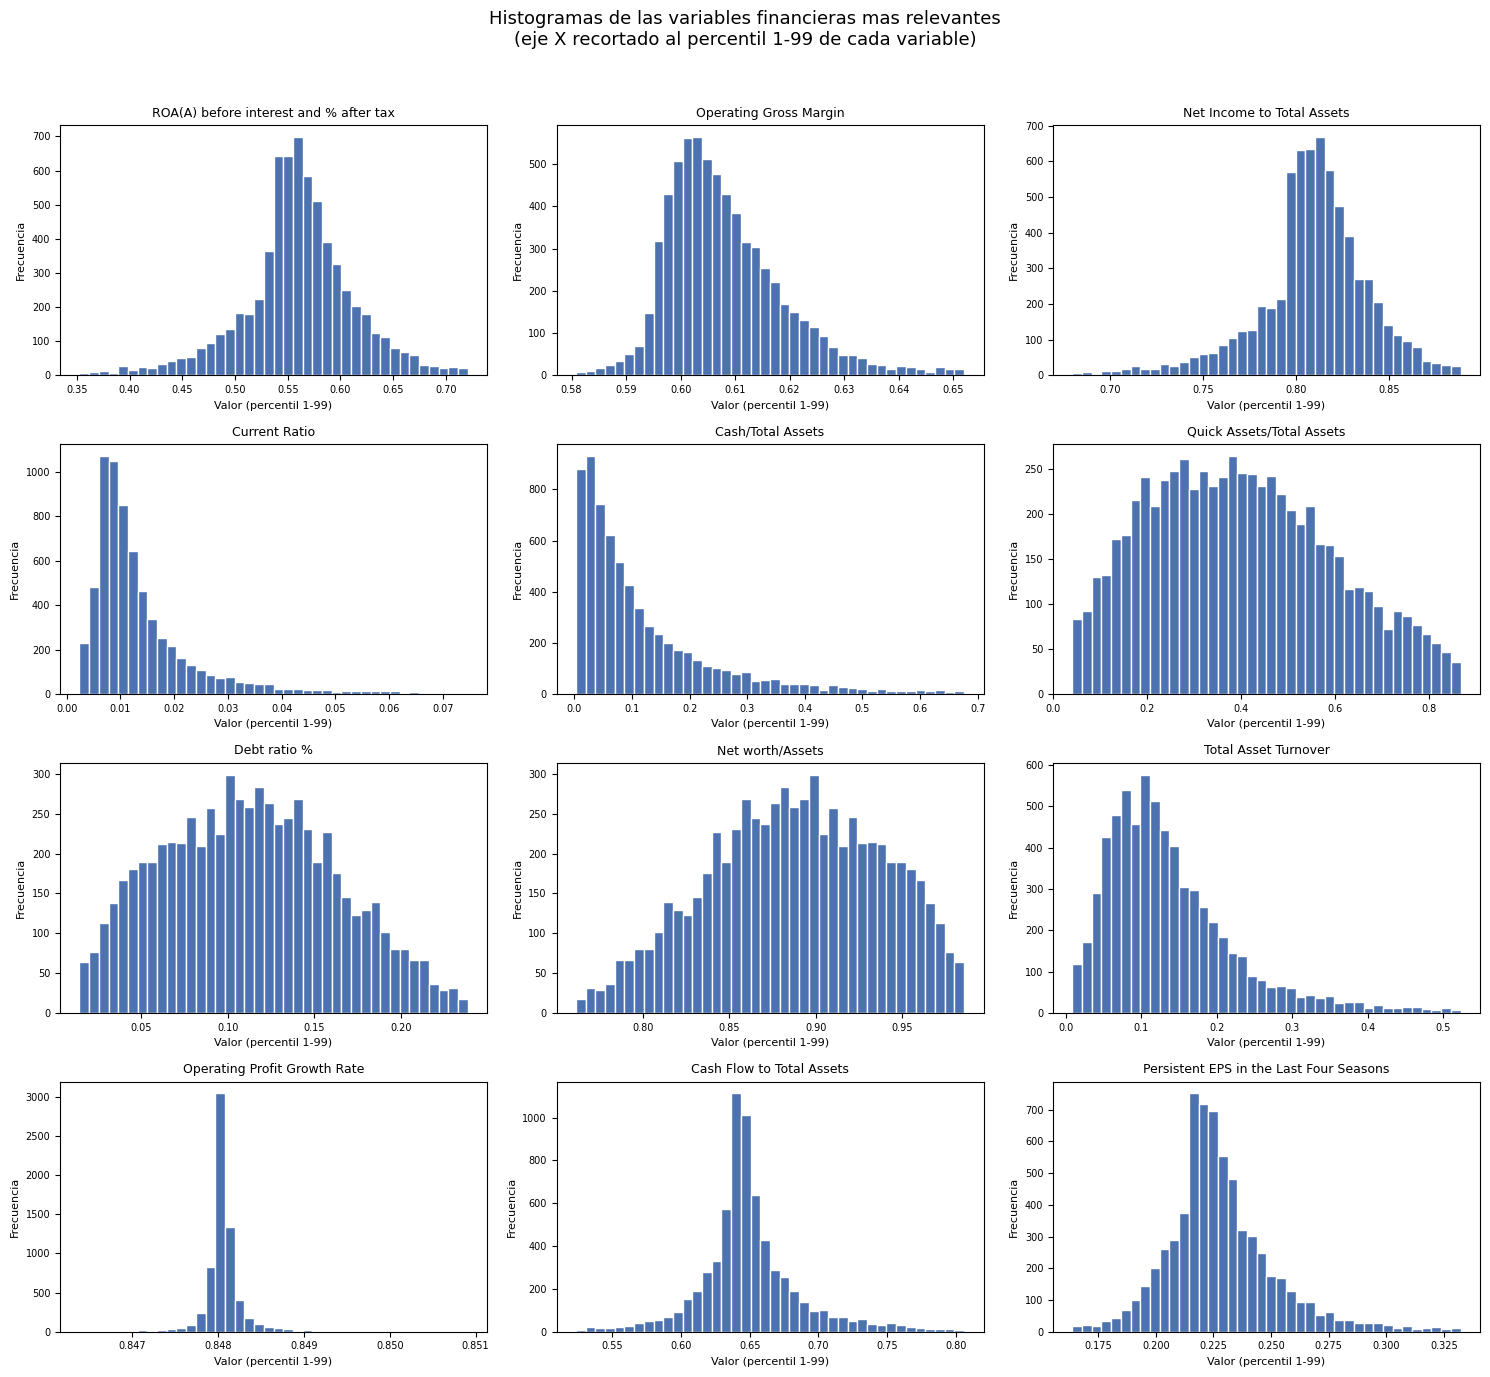

In [ ]:
vars_seleccionadas = list(variables_relevantes.keys())

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for ax, col in zip(axes, vars_seleccionadas):
    datos = df[col]
    p1, p99 = datos.quantile([0.01, 0.99])
    ax.hist(datos, bins=40, range=(p1, p99), color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Valor (percentil 1-99)", fontsize=8)
    ax.set_ylabel("Frecuencia", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle("Histogramas de las variables financieras mas relevantes\n(eje X recortado al percentil 1-99 de cada variable)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


- Las variables de **rentabilidad** (`ROA(A)`, `Operating Gross Margin`, `Net Income to Total Assets`) muestran distribuciones aproximadamente simétricas y unimodales, concentradas alrededor de su media, con una cola relativamente más larga hacia la izquierda (empresas con rentabilidad baja).
- Las variables de **liquidez** (`Current Ratio`, `Cash/Total Assets`) están fuertemente sesgadas a la derecha (la mayoría de las empresas mantiene una liquidez baja, con pocas manteniendo cantidades grandes de efectivo u holguras muy altas); `Quick Assets/Total Assets` es la más simétrica del grupo.
- `Debt ratio %` y `Net worth/Assets` son prácticamente complementarias, y ambas muestran una forma acampanada centrada cerca de 0.10-0.15 y 0.85-0.90 respectivamente: la empresa mediana de la muestra está financiada mayoritariamente con patrimonio, no con deuda.
- `Total Asset Turnover` está sesgada a la derecha (la mayoría de las empresas rota sus activos lentamente, con una cola de empresas muy eficientes).
- `Operating Profit Growth Rate` muestra un pico extremadamente angosto: casi todas las empresas caen en un rango de apenas 0.0045 de ancho (0.8464 a 0.8509 en el percentil 1-99). Es un efecto conocido de este dataset: al normalizar cada variable de crecimiento al rango [0, 1] usando el máximo global (que incluye outliers de 10⁹), la variación "normal" entre empresas queda comprimida en una franja muy angosta cerca de un mismo valor, por lo que esta variable en su forma actual aporta poca capacidad discriminante entre empresas.
- `Cash Flow to Total Assets` y `Persistent EPS in the Last Four Seasons` presentan formas acampanadas con colas moderadas a ambos lados.

### 2.5 Diagramas de caja (boxplots)



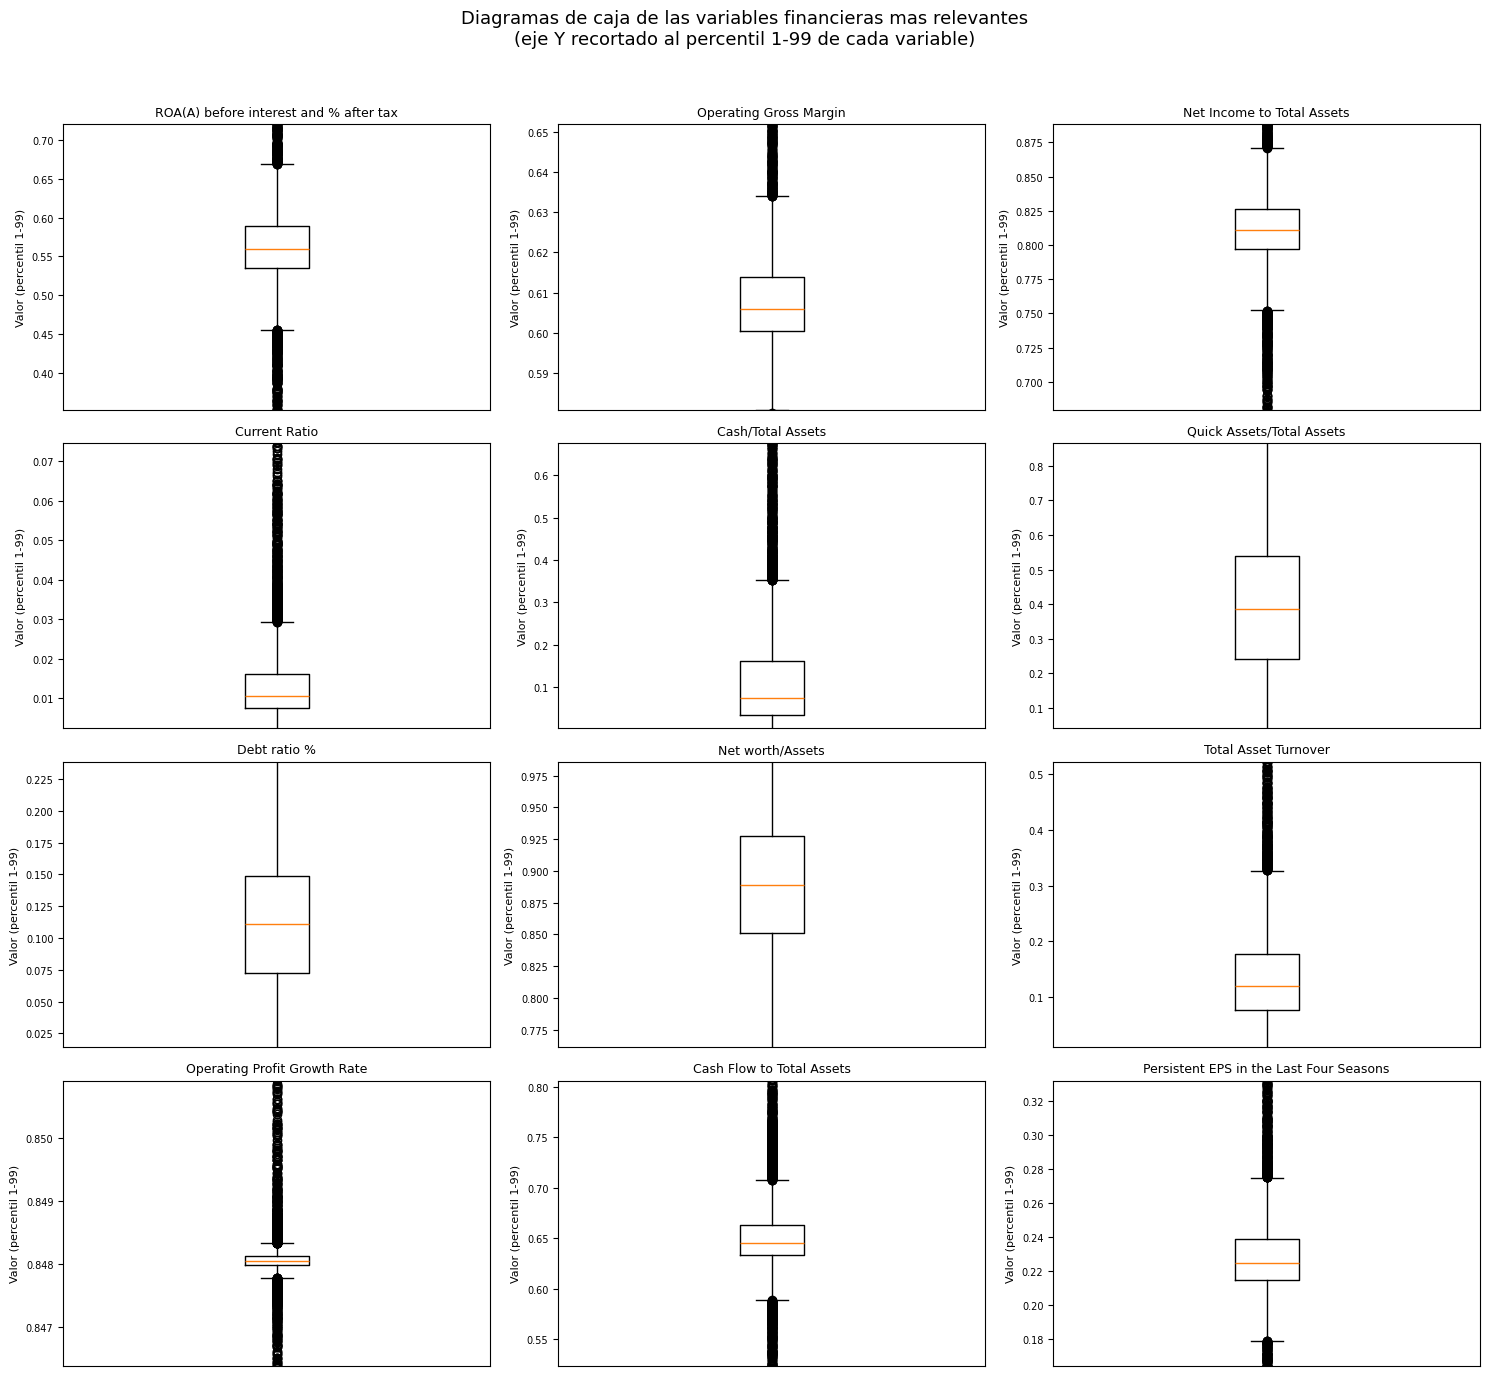

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for ax, col in zip(axes, vars_seleccionadas):
    datos = df[col]
    p1, p99 = datos.quantile([0.01, 0.99])
    ax.boxplot(datos, vert=True, showfliers=True)
    ax.set_ylim(p1, p99)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Valor (percentil 1-99)", fontsize=8)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

fig.suptitle("Diagramas de caja de las variables financieras mas relevantes\n(eje Y recortado al percentil 1-99 de cada variable)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


- Los boxplots de la cuadrícula confirman la asimetría ya vista en los histogramas (colas largas en `Current Ratio`, `Cash/Total Assets`, `Total Asset Turnover`) y muestran gran cantidad de valores marcados como atípicos incluso dentro del percentil 1-99, algo típico de razones financieras calculadas sobre muchas empresas pequeñas o con comportamientos inusuales.
- `Cash Flow to Total Assets`, en cambio, muestra medianas muy parecidas entre los dos grupos (0.646 vs. 0.638), por lo que de forma univariada discrimina menos que las dos anteriores; esto no significa que sea irrelevante para los modelos (Secciones 5 en adelante), ya que su valor predictivo puede aparecer en combinación con otras variables.
- Esta diferencia de comportamiento entre variables (algunas separan bien las clases por sí solas, otras no) motiva pasar a modelos que combinen las 95 variables — el objetivo de las secciones siguientes.

# 3. Matriz de Correlación

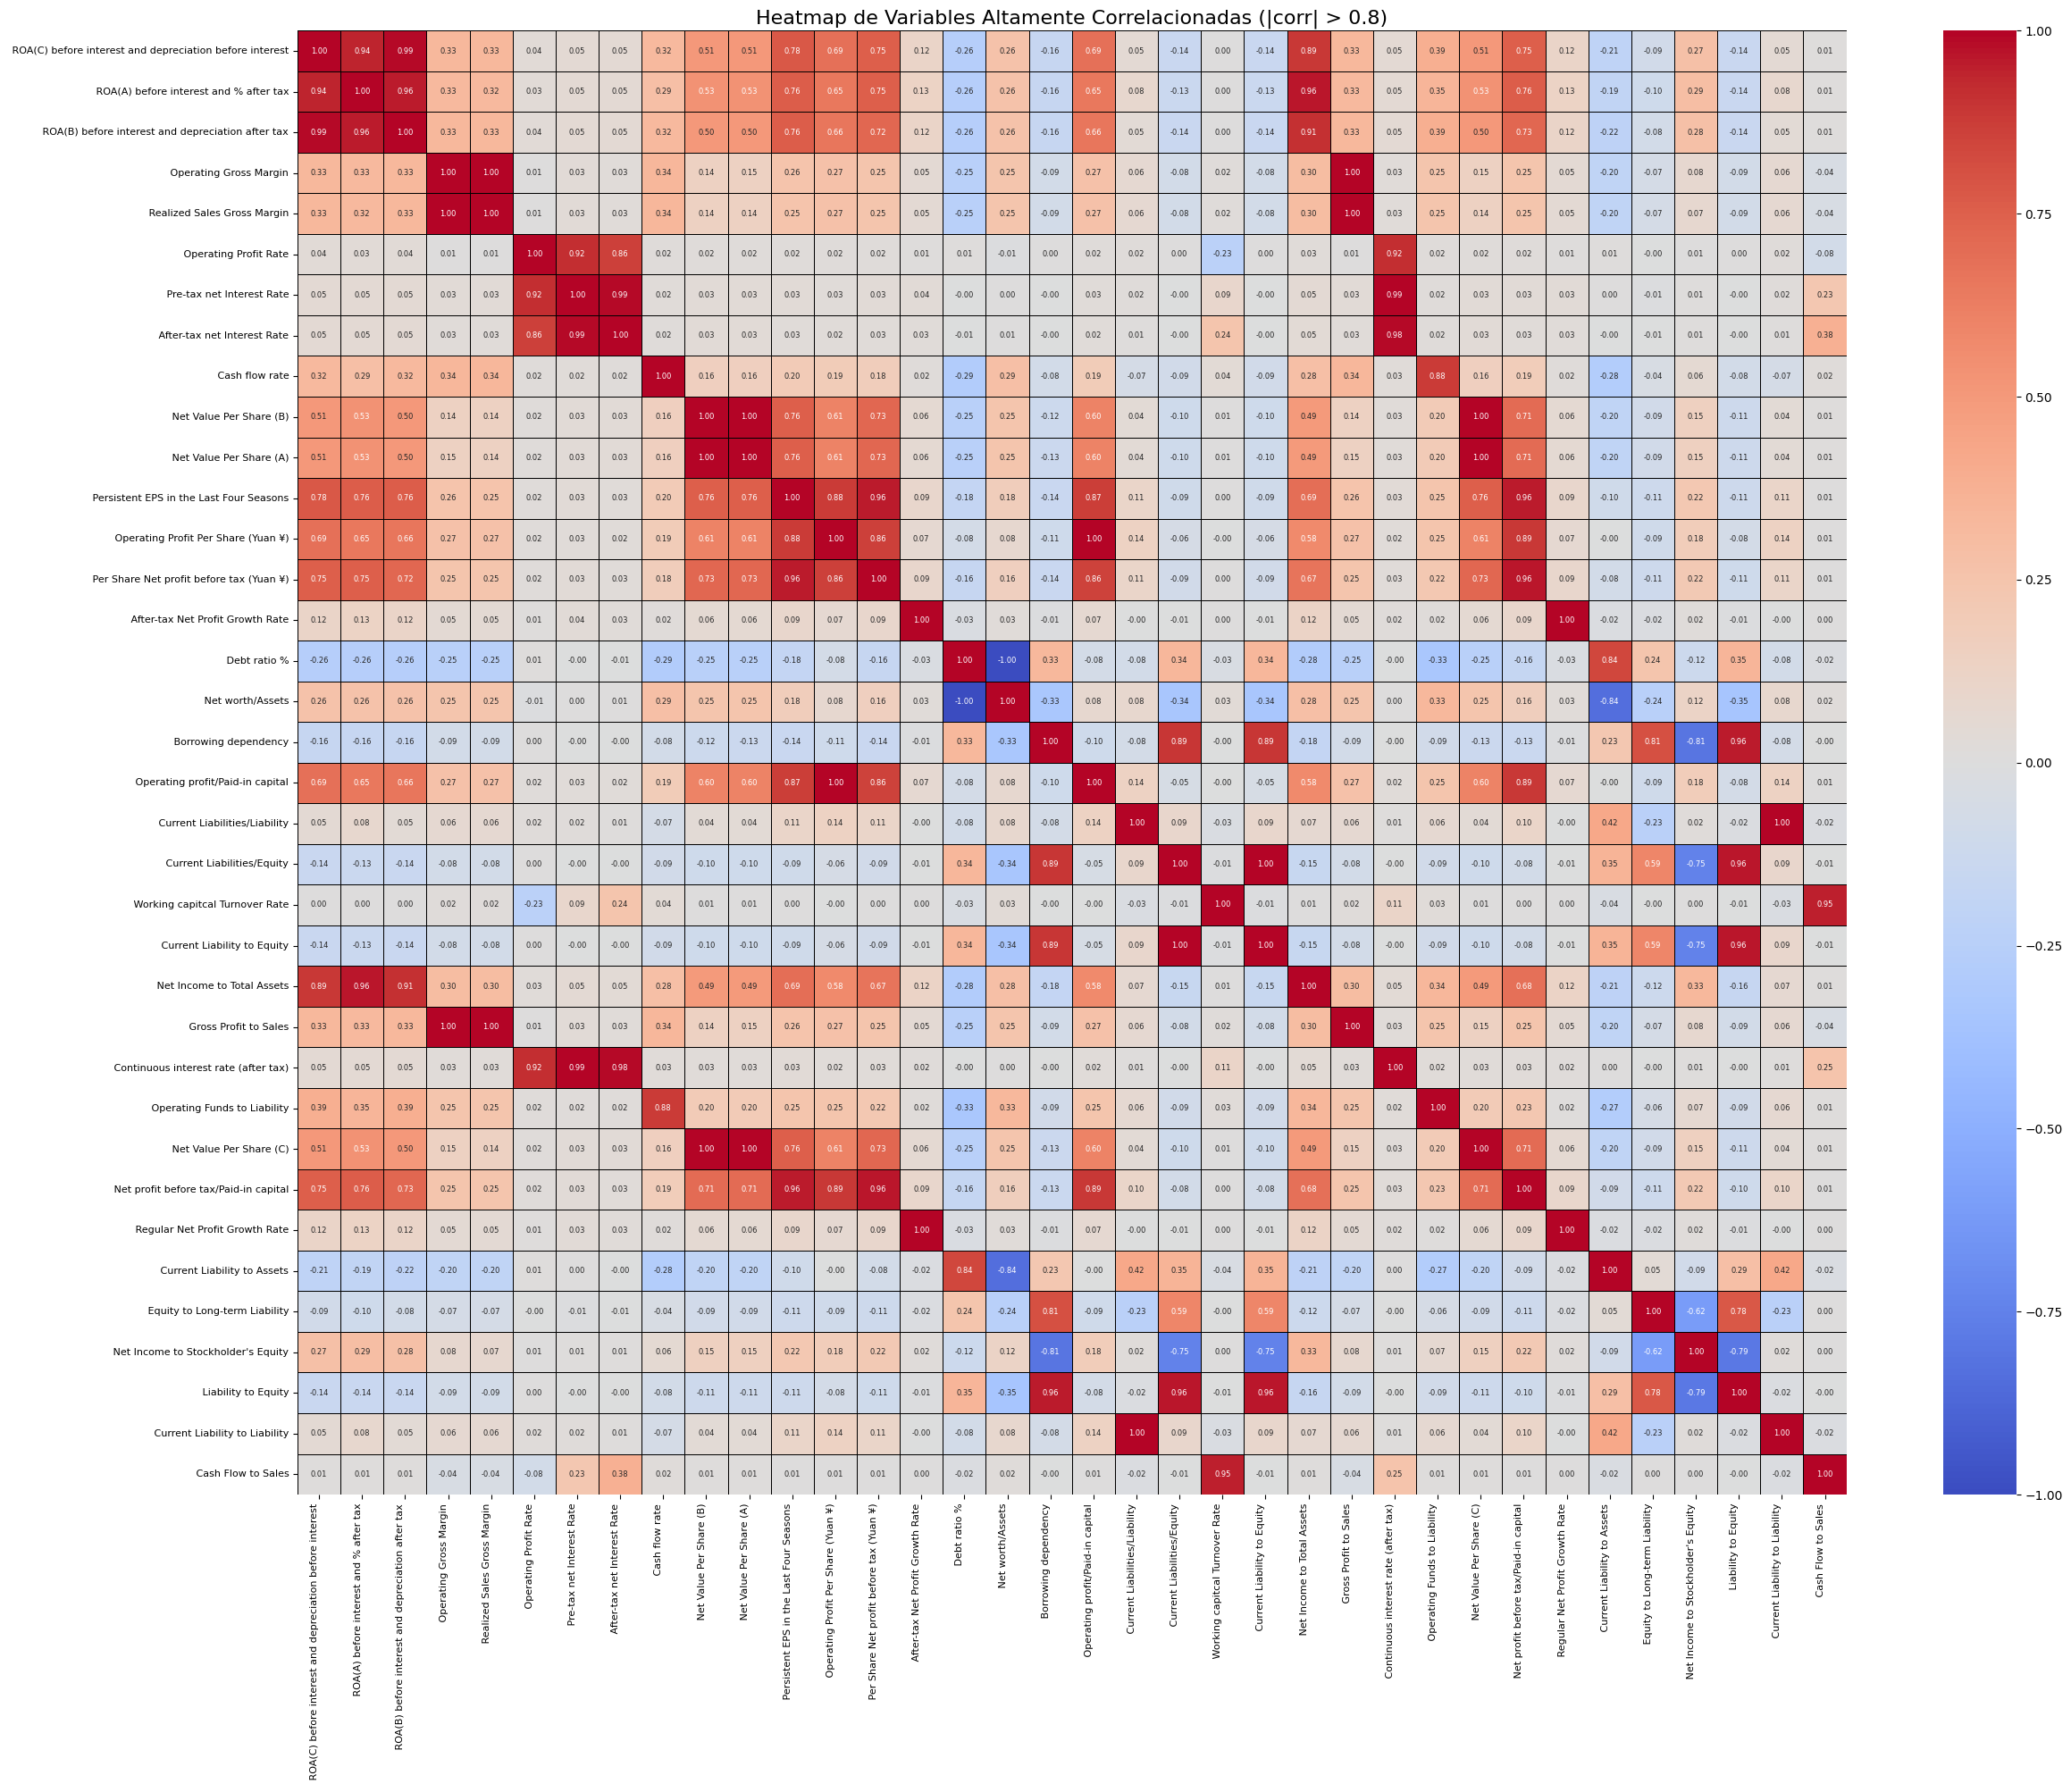

In [18]:
UMBRAL_CORR = 0.8

corr_matrix = df[numeric_cols].corr(numeric_only=True).fillna(0)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > UMBRAL_CORR:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    df_high_corr = pd.DataFrame(high_corr_pairs, columns=['Variable 1', 'Variable 2', 'Correlación'])
    all_high_corr_vars = pd.unique(df_high_corr[['Variable 1', 'Variable 2']].values.ravel('K')).tolist()
    corr_subset = df[all_high_corr_vars].corr(numeric_only=True).fillna(0)

    num_vars = len(all_high_corr_vars)
    fig_size = max(8, num_vars * 0.7)
    plt.figure(figsize=(fig_size, fig_size * 0.8))
    sns.heatmap(corr_subset, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, linecolor='black',
                annot_kws={"fontsize": max(6, 180 / num_vars)})
    plt.title(f'Heatmap de Variables Altamente Correlacionadas (|corr| > {UMBRAL_CORR})', fontsize=16)
    plt.xticks(rotation=90, ha='right', fontsize=max(8, 200 / num_vars))
    plt.yticks(rotation=0, fontsize=max(8, 200 / num_vars))
    plt.tight_layout()
    plt.show()
else:
    df_high_corr = pd.DataFrame(columns=['Variable 1', 'Variable 2', 'Correlación'])
    print(f"No se encontraron variables con |correlación| > {UMBRAL_CORR}.")


### 3.1 Listado de pares de variables con correlación > 0.8

In [19]:
high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print(f"Pares de variables con correlación absoluta > {UMBRAL_CORR} (excluyendo la diagonal principal):")
if high_corr_pairs_sorted:
    df_high_corr = pd.DataFrame(high_corr_pairs_sorted, columns=['Variable 1', 'Variable 2', 'Correlación'])
    display(df_high_corr)
else:
    print(f"No se encontraron pares de variables con correlación absoluta > {UMBRAL_CORR}.")

print(f"\nTotal de pares altamente correlacionados: {len(high_corr_pairs_sorted)}")


Pares de variables con correlación absoluta > 0.8 (excluyendo la diagonal principal):


,Variable 1,Variable 2,Correlación
0,Current Liabilities/Liability,Current Liability to Liability,1.000000
1,Current Liabilities/Equity,Current Liability to Equity,1.000000
2,Debt ratio %,Net worth/Assets,-1.000000
3,Operating Gross Margin,Gross Profit to Sales,1.000000
4,Net Value Per Share (A),Net Value Per Share (C),0.999837
5,Operating Gross Margin,Realized Sales Gross Margin,0.999518
6,Realized Sales Gross Margin,Gross Profit to Sales,0.999518
7,Net Value Per Share (B),Net Value Per Share (A),0.999342
8,Net Value Per Share (B),Net Value Per Share (C),0.999179
9,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998696



Total de pares altamente correlacionados: 43


### 3.2 Decisión sobre las variables correlacionadas

Se identificaron varios pares de variables con alta colinealidad (esperable en razones financieras derivadas de los mismos rubros contables, p. ej. las tres versiones de ROA). Sin embargo, **no se elimina ninguna variable del conjunto de entrenamiento**: los cinco modelos pedidos en este trabajo (árbol de decisión, bagging, random forest, AdaBoost y XGBoost) están basados en árboles, y los árboles son robustos a la multicolinealidad — en cada nodo seleccionan la variable que mejor separa las clases, sin que esto distorsione el resultado como sí ocurriría en una regresión lineal/logística clásica. El análisis de correlación se conserva como diagnóstico exploratorio, pero `X` conserva las 95 variables originales en las secciones 5, 6 y 7.



# 4. Partición de datos y metodología de validación cruzada (10 folds)

Antes de entrenar los modelos se define una única estrategia de evaluación que se reutiliza sin cambios en las secciones 5, 6 y 7, para que los cinco modelos se comparen bajo exactamente las mismas condiciones:

- **Validación cruzada estratificada de 10 folds** (`StratifiedKFold`)
- Un conjunto común de **métricas**: `accuracy`, `precision`, `recall`, `f1`, `roc_auc`.


In [20]:
X = df.drop(columns=['Bankrupt'])
y = df['Bankrupt']

print(f"Dimensiones de X: {X.shape}")
print("Distribución de la variable objetivo:")
print(y.value_counts(normalize=True).round(4))

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}     # métricas de cada modelo con hiperparámetros "base" (Sección 5)
resultados_grid = {}   # mejores hiperparámetros y su score (Sección 6)
mejores_modelos = {}   # mejor estimador de cada familia, ya ajustado por GridSearchCV


def evaluar_modelo_cv(nombre, modelo, X=X, y=y, cv=cv_strategy, scoring=scoring_metrics, guardar_en=None):
    """Evalúa un modelo con validación cruzada de 10 folds y muestra un resumen."""
    resultado = cross_validate(modelo, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    fila = {m: resultado[f"test_{m}"].mean() for m in scoring}
    if guardar_en is not None:
        guardar_en[nombre] = fila
    print(f"{nombre}:")
    for m in scoring:
        print(f"   {m:10s}: {fila[m]:.4f}")
    return fila


Dimensiones de X: (6819, 95)
Distribución de la variable objetivo:
Bankrupt
0    0.9677
1    0.0323
Name: proportion, dtype: float64


# 5. Modelos predictivos con validación cruzada de 10 folds


## 5.1 Árboles de decisión

In [21]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
evaluar_modelo_cv("Decision Tree", dt_model, guardar_en=resultados_cv)


Decision Tree:
   accuracy  : 0.8824
   precision : 0.1789
   recall    : 0.7273
   f1        : 0.2857
   roc_auc   : 0.8023


{'accuracy': np.float64(0.882384668053277),
 'precision': np.float64(0.17886883627702205),
 'recall': np.float64(0.7272727272727273),
 'f1': np.float64(0.2856790843662262),
 'roc_auc': np.float64(0.8023280274813246)}

## 5.2 Comité de máquinas (Bagging) con regresión y árboles




In [22]:
# Bagging con un estimador de regresión (Regresión Logística)
base_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, class_weight='balanced'))
])
bagging_logreg = BaggingClassifier(estimator=base_logreg, n_estimators=50, random_state=42, n_jobs=-1)
evaluar_modelo_cv("Bagging (Regresión Logística)", bagging_logreg, guardar_en=resultados_cv)

# Bagging con árboles de decisión como estimador base
bagging_arboles = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    n_estimators=50, random_state=42, n_jobs=-1
)
evaluar_modelo_cv("Bagging (Árboles)", bagging_arboles, guardar_en=resultados_cv)


Bagging (Regresión Logística):
   accuracy  : 0.8869
   precision : 0.1856
   recall    : 0.7364
   f1        : 0.2957
   roc_auc   : 0.8798
Bagging (Árboles):
   accuracy  : 0.9694
   precision : 0.6508
   recall    : 0.1864
   f1        : 0.2776
   roc_auc   : 0.8979


{'accuracy': np.float64(0.9693501018426414),
 'precision': np.float64(0.6507692307692308),
 'recall': np.float64(0.18636363636363637),
 'f1': np.float64(0.2775867446393762),
 'roc_auc': np.float64(0.8978578131988948)}

Para la malla de hiperparámetros y la comparación final se toma Bagging (Árboles) como representante de 5.2, por ser la configuración estándar de Bagging y la más sensible a sus propios hiperparámetros (`n_estimators`, `max_samples`); la variante de regresión queda documentada arriba para cumplir el enunciado.

## 5.3 Random Forest

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluar_modelo_cv("Random Forest", rf_model, guardar_en=resultados_cv)


Random Forest:
   accuracy  : 0.9688
   precision : 0.6356
   recall    : 0.1409
   f1        : 0.2183
   roc_auc   : 0.9349


{'accuracy': np.float64(0.9687633762665737),
 'precision': np.float64(0.6355982905982905),
 'recall': np.float64(0.1409090909090909),
 'f1': np.float64(0.21830918559389806),
 'roc_auc': np.float64(0.9348504809440799)}

## 5.4 AdaBoost

In [25]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),  # sin class_weight, ver nota de la Sección 5
    n_estimators=100,
    random_state=42
)
evaluar_modelo_cv("AdaBoost", adaboost_model, guardar_en=resultados_cv)


AdaBoost:
   accuracy  : 0.9672
   precision : 0.5057
   recall    : 0.2682
   f1        : 0.3391
   roc_auc   : 0.9258


{'accuracy': np.float64(0.9671502577286292),
 'precision': np.float64(0.5056539074960128),
 'recall': np.float64(0.2681818181818182),
 'f1': np.float64(0.3390737153207649),
 'roc_auc': np.float64(0.9258369388463195)}

## 5.5 XGBoost

In [26]:
n_neg, n_pos = np.bincount(y)
scale_pos_weight = n_neg / n_pos  # compensa el desbalance, equivalente al class_weight='balanced' de los otros modelos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgboost_model = xgb.XGBClassifier(
    n_estimators=100,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
evaluar_modelo_cv("XGBoost", xgboost_model, guardar_en=resultados_cv)


scale_pos_weight = 30.00
XGBoost:
   accuracy  : 0.9689
   precision : 0.5453
   recall    : 0.3955
   f1        : 0.4505
   roc_auc   : 0.9300


{'accuracy': np.float64(0.9689093578961419),
 'precision': np.float64(0.545342333964625),
 'recall': np.float64(0.39545454545454545),
 'f1': np.float64(0.45053647395603036),
 'roc_auc': np.float64(0.9299600362850466)}

In [27]:
print("\n=== Resumen: modelos base, hiperparámetros por defecto (10-fold CV) ===")
df_resultados_base = pd.DataFrame(resultados_cv).T
display(df_resultados_base.round(4))



=== Resumen: modelos base, hiperparámetros por defecto (10-fold CV) ===


,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.8824,0.1789,0.7273,0.2857,0.8023
Bagging (Regresión Logística),0.8869,0.1856,0.7364,0.2957,0.8798
Bagging (Árboles),0.9694,0.6508,0.1864,0.2776,0.8979
Random Forest,0.9688,0.6356,0.1409,0.2183,0.9349
AdaBoost,0.9672,0.5057,0.2682,0.3391,0.9258
XGBoost,0.9689,0.5453,0.3955,0.4505,0.9300


##  Interpretación

**Árbol único y Bagging con regresión logística son** "sensibles": detectan ~73% de las quiebras reales (recall alto), pero a costa de muchísimas falsas alarmas (precisión ~18%). Esto ocurre porque class_weight='balanced' empuja fuerte hacia predecir la clase minoritaria, y sin el efecto estabilizador de muchos árboles independientes, ese empuje se traduce directamente en falsos positivos.

**Bagging con árboles y Random Forest son** "conservadores": alta precisión (63–65%) pero recall muy bajo (14–19%). El promedio de muchos árboles diluye el efecto del balanceo de clases, así que terminan siendo cautelosos para etiquetar "quiebra".

**AdaBoost y XGBoost (boosting secuencial)**: logran, desde el inicio y sin ajuste, el mejor equilibrio. XGBoost es el mejor modelo base por F1 (0.4505), gracias a scale_pos_weight=30 que compensa el desbalance de forma más fina que un class_weight binario.

# 6. Malla de valores: búsqueda de hiperparámetros (Grid Search)

Para cada uno de los cinco modelos se define una malla de hiperparámetros y se usa `GridSearchCV` con la misma validación cruzada de 10 folds (`cv_strategy`).



In [31]:
param_grids = {
    "Decision Tree": {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 10],
        'criterion': ['gini', 'entropy'],
    },
    "Bagging (Árboles)": {
        'n_estimators': [ 50, 100],
        'max_samples': [0.7, 1.0],
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'max_features': ['sqrt', 'log2'],
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.1, 0.5, 1.0],
    },
    "XGBoost": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
    },
}

modelos_base = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Bagging (Árboles)": BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
        random_state=42, n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight),
}

for nombre, modelo in modelos_base.items():
    print(f"--- Optimizando: {nombre} ---")
    grid_search = GridSearchCV(
        estimator=modelo,
        param_grid=param_grids[nombre],
        cv=cv_strategy,
        scoring='f1',
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(X, y)
    mejores_modelos[nombre] = grid_search.best_estimator_
    resultados_grid[nombre] = {
        'best_f1_cv': grid_search.best_score_,
        'best_params': grid_search.best_params_
    }
    print(f"Mejor F1 (CV): {grid_search.best_score_:.4f}")
    print(f"Mejores parámetros: {grid_search.best_params_}\n")


--- Optimizando: Decision Tree ---
Mejor F1 (CV): 0.3625
Mejores parámetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}

--- Optimizando: Bagging (Árboles) ---
Mejor F1 (CV): 0.2811
Mejores parámetros: {'max_samples': 1.0, 'n_estimators': 100}

--- Optimizando: Random Forest ---
Mejor F1 (CV): 0.4381
Mejores parámetros: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}

--- Optimizando: AdaBoost ---
Mejor F1 (CV): 0.4134
Mejores parámetros: {'learning_rate': 0.5, 'n_estimators': 200}

--- Optimizando: XGBoost ---
Mejor F1 (CV): 0.4819
Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}



In [32]:
print("=== Métricas completas de los modelos ya optimizados (10-fold CV) ===")
resultados_tuned = {}
for nombre, modelo in mejores_modelos.items():
    evaluar_modelo_cv(f"{nombre} (optimizado)", modelo, guardar_en=resultados_tuned)


=== Métricas completas de los modelos ya optimizados (10-fold CV) ===
Decision Tree (optimizado):
   accuracy  : 0.9365
   precision : 0.2710
   recall    : 0.5545
   f1        : 0.3625
   roc_auc   : 0.7540
Bagging (Árboles) (optimizado):
   accuracy  : 0.9693
   precision : 0.6291
   recall    : 0.1909
   f1        : 0.2811
   roc_auc   : 0.9140
Random Forest (optimizado):
   accuracy  : 0.9588
   precision : 0.4001
   recall    : 0.5000
   f1        : 0.4381
   roc_auc   : 0.9408
AdaBoost (optimizado):
   accuracy  : 0.9720
   precision : 0.6611
   recall    : 0.3091
   f1        : 0.4134
   roc_auc   : 0.9307
XGBoost (optimizado):
   accuracy  : 0.9619
   precision : 0.4371
   recall    : 0.5500
   f1        : 0.4819
   roc_auc   : 0.9361


**Random Forest es el gran ganador del tuning**: limitar max_depth=10 (en vez de árboles sin límite) evita el sobreajuste conservador que lo hacía casi inútil para detectar quiebras. El recall se duplicó (0.14 → 0.50) con una caída moderada en precisión, y de paso logró el mejor ROC-AUC de todo el proyecto (0.9408).

**Bagging con árboles apenas mejora** (0.2776 → 0.2811): la búsqueda de hiperparámetros no puede resolver un problema estructural del algoritmo para este dataset tan desbalanceado.

**AdaBoost optimizado logra la mejor precisión de todo**s (0.6611): es el modelo "más confiable" cuando sí predice quiebra, aunque sigue perdiendo casi 7 de cada 10 quiebras reales.

XGBoost sigue siendo el mejor en F1 tras el tuning, y de hecho su versión base (sin optimizar) ya superaba en F1 a casi todos los demás modelos optimizados — señal de que el algoritmo de gradient boosting es intrínsecamente el más adecuado para esta estructura de datos.

# 7. Comparación de los modelos y selección del mejor

Se compara el desempeño **base** contra el **optimizado**, ambos medidos con la misma validación cruzada de 10 folds. La tabla se ordena por **F1**, no por Accuracy.




In [33]:
df_base = pd.DataFrame(resultados_cv).T
df_base.index = [f"{i} (base)" for i in df_base.index]

df_tuned = pd.DataFrame(resultados_tuned).T

df_comparacion = pd.concat([df_base, df_tuned]).sort_values('f1', ascending=False)
display(df_comparacion.round(4))

mejor_modelo_nombre = df_tuned['f1'].idxmax()
mejor_f1 = df_tuned.loc[mejor_modelo_nombre, 'f1']

print(f"\nEl mejor modelo, entre los 5 solicitados y ya con hiperparámetros optimizados, es: {mejor_modelo_nombre}")
print(f"F1 promedio (10-fold CV): {mejor_f1:.4f}")
print(f"Hiperparámetros: {resultados_grid[mejor_modelo_nombre.replace(' (optimizado)', '')]['best_params']}")


,accuracy,precision,recall,f1,roc_auc
XGBoost (optimizado),0.9619,0.4371,0.5500,0.4819,0.9361
XGBoost (base),0.9689,0.5453,0.3955,0.4505,0.9300
Random Forest (optimizado),0.9588,0.4001,0.5000,0.4381,0.9408
AdaBoost (optimizado),0.9720,0.6611,0.3091,0.4134,0.9307
Decision Tree (optimizado),0.9365,0.2710,0.5545,0.3625,0.7540
AdaBoost (base),0.9672,0.5057,0.2682,0.3391,0.9258
Bagging (Regresión Logística) (base),0.8869,0.1856,0.7364,0.2957,0.8798
Decision Tree (base),0.8824,0.1789,0.7273,0.2857,0.8023
Bagging (Árboles) (optimizado),0.9693,0.6291,0.1909,0.2811,0.9140
Bagging (Árboles) (base),0.9694,0.6508,0.1864,0.2776,0.8979



El mejor modelo, entre los 5 solicitados y ya con hiperparámetros optimizados, es: XGBoost (optimizado)
F1 promedio (10-fold CV): 0.4819
Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


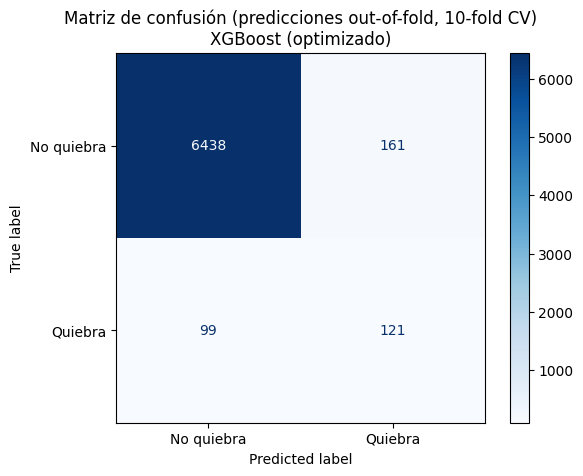

In [34]:
mejor_modelo = mejores_modelos[mejor_modelo_nombre.replace(' (optimizado)', '')]
y_pred_cv = cross_val_predict(mejor_modelo, X, y, cv=cv_strategy, n_jobs=-1)

cm = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=["No quiebra", "Quiebra"])
disp.plot(cmap="Blues", values_format='d')
plt.title(f"Matriz de confusión (predicciones out-of-fold, 10-fold CV)\n{mejor_modelo_nombre}")
plt.show()


De las 220 empresas que realmente quebraron, el modelo detectó correctamente 121 (55%) y dejó pasar 99 (45%) como falsos negativos. En un contexto de riesgo crediticio, este es el error más costoso: significa aprobar crédito o mantener exposición en una empresa que efectivamente va a quebrar.

De las 6,599 empresas sanas, 6,438 (97.6%) fueron correctamente identificadas, y solo 161 (2.4%) generaron una falsa alarma (empresa sana marcada como riesgo). Este error es menos grave — implica negar o encarecer crédito a una empresa que en realidad era solvente.

In [35]:
import joblib

# Guardar el mejor modelo entrenado (XGBoost optimizado)
filename = 'mejor_modelo_bankruptcy.joblib'
joblib.dump(mejor_modelo, filename)

print(f"El mejor modelo ({mejor_modelo_nombre}) ha sido guardado exitosamente como '{filename}'")

El mejor modelo (XGBoost (optimizado)) ha sido guardado exitosamente como 'mejor_modelo_bankruptcy.joblib'


##**Conclusiones**

- Existe un trade-off consistente entre "modelos sensibles" (árbol único, bagging con regresión logística) y "modelos conservadores" (bagging con árboles, random forest) cuando se usan hiperparámetros por defecto. El boosting (AdaBoost, XGBoost) evita este extremo desde el principio.

- El tuning de hiperparámetros tuvo el mayor impacto en Random Forest, que pasó de ser casi inútil (F1=0.22) a un modelo competitivo (F1=0.44) simplemente limitando la profundidad de los árboles.

- XGBoost optimizado es el mejor modelo del proyecto, con el mejor F1 (0.4819) y un buen balance recall/precisión, aunque Random Forest optimizado queda muy cerca y con el mejor ROC-AUC — en un caso de uso real donde importe más el ranking de riesgo que la clasificación binaria en sí, RF sería una alternativa válida a considerar.